# Tidal-Spin Calculations under a Representative EoS

## Representative EoS: POLYn1

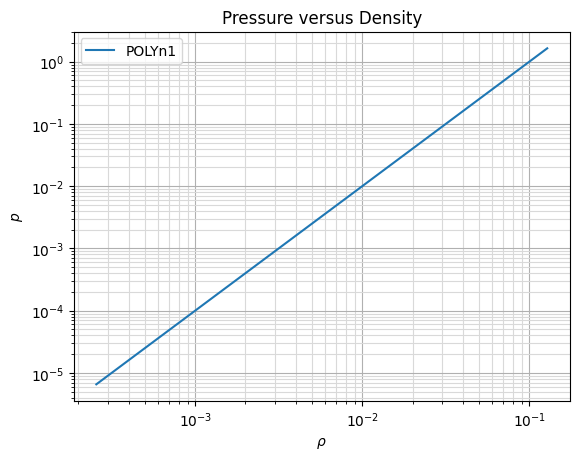

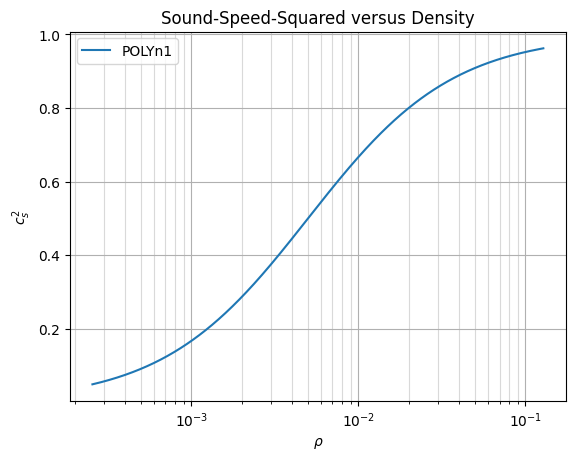

In [1]:
import pandas as pd
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from astropy import units, constants as const
from scipy.integrate import ode
import pandas as pd
import itertools


#CoRe import

polyn1 = np.loadtxt('g2k100_mvsr.dat')
pfD = pd.DataFrame(polyn1, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
dataM_POLYn1 = pfD["M"].to_numpy()
dataR_POLYn1 = pfD["R"].to_numpy()
dataL_POLYn1 = pfD["Lambda"].to_numpy()

#MacKay Solver import

POLYn1 = np.loadtxt('POLYn1_MacKay.dat')
PfD = pd.DataFrame(POLYn1, columns=["rho_central", "M", "R"])
M_POLY = PfD["M"].to_numpy()
R_POLY = PfD["R"].to_numpy()
r_POLY = PfD["rho_central"].to_numpy()

#EoS cell

def eos_p(rho, K, Gamma):
    return K * rho**Gamma

def eos_rho(p, K, Gamma):
    rho_rest = (p / K)**(1/Gamma)
    return rho_rest + p/(Gamma-1)

def eos_cs2(rho, K, Gamma):
    dpdrho = Gamma * K * rho**(Gamma - 1)
    dedrho = 1 + dpdrho/(Gamma - 1)
    return dpdrho / dedrho

# Create an EOS function
def POLYn1_eos_p_and_rho():
    K = 100
    Gamma = 2
    return (
        lambda rho: eos_p(rho, K, Gamma),
        lambda p: eos_rho(p, K, Gamma),
    )

def POLYn1_eos_cs2_and_rho():
    K = 100
    Gamma = 2
    return (
        lambda rho: eos_cs2(rho, K, Gamma),
        lambda p: eos_rho(p, K, Gamma),
    )

rho_base = 1.28e-3
rho_min = 1/5 * rho_base
rho_max = 100 * rho_base
rho_c_space = np.logspace(np.log10(rho_min),
                          np.log10(rho_max), 1000)

# Plot the EOS
f1=plt.figure()
eos_p_func, eos_rho_func = POLYn1_eos_p_and_rho()
plt.loglog(rho_c_space, eos_p_func(rho_c_space), label="POLYn1")
plt.title("Pressure versus Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$p$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

f2=plt.figure()
eos_cs2_func, _ = POLYn1_eos_cs2_and_rho()
plt.semilogx(rho_c_space, eos_cs2_func(rho_c_space), label="POLYn1")
plt.title("Sound-Speed-Squared versus Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$c_s^2$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

#f2.savefig("all_eos_cs2vrho.png", bbox_inches='tight', dpi=300)

## TOV(+tidal+spin) ODEs and Solver

In [2]:
## The TOV Solver (with rotations + Tidal ODE) ##
#-----------------------------------#
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from astropy import units, constants as const
from scipy.integrate import ode
from scipy.integrate import solve_ivp
import pandas as pd

#TOV equations (Schwarzschild Coord.s!!)

def dp_dr(r, p, m, rho):
    if r <= 0:
        return 0
    return -(rho + p) * (m + 4 * pi * r**3 * p) / r / (r - 2 * m) # 2*m indicates that the coordinates are Schwarzschild
    
def dm_dr(r, p, m, rho):
    return 4 * pi * r**2 * rho

#y2
def dy2_dr(r, y2, p, m, rho, cs2):
    if r<=1e-6:
        return 2
    F = 1/r + (2*m/r**2 + 4*pi*r*(p-rho))/(1 - 2*m/r)
    G = (-2*(2+1)/r**2 + 4*pi*((p+rho)/(cs2) + 5*rho + 9*p) - (4*pi*r*p + m/r**2)**2/(1-2*m/r))/(1 - 2*m/r)
    return -(y2**2/r + y2*F + r*G)

#H2
H20 = 1e-10
def dH2_dr(r, H2, y2):
    if r<=1e-6:
        return H20
    return (y2*H2)/r

#rotational TOV equation
Om=1e-3 #test value

def dv_dr(r, p, m, v, rho):
    if r <= 1e-6:
        return 0
    B = (4*pi*(p+rho))/(1-2*m/r)
    return -3*v/r - v**2/r + r*B*(v+4)
    
def dw_dr(r, v, w):
    if r<=1e-6:
        return Om
    return v*w/r

#==================
# Octopole numbers
#==================
#y3
def dy3_dr(r, y3, p, m, rho, cs2):
    if r<=1e-6:
        return 3
    F = 1/r + (2*m/r**2 + 4*pi*r*(p-rho))/(1 - 2*m/r)
    G = (-3*(3+1)/r**2 + 4*pi*((p+rho)/(cs2) + 5*rho + 9*p) - (4*pi*r*p + m/r**2)**2/(1-2*m/r))/(1 - 2*m/r)
    return -(y3**2/r + y3*F + r*G)
    
#y*3
def dys3_dr(r, ys3, p, m, rho):
    if r<=1e-6:
        return 3+1
    A = 1/r + (4*pi*r**2*(p + rho))/(r - 2*m)
    B = (3*(3+1)/r - 4*m/r**2 + 8*pi*r*(p+rho))/(r - 2*m)
    return -(ys3**2/r - ys3*A - r*B)

def tov_equations(r, state, eos_rho, eos_cs2):
    p, m, y2, H2, v, w, y3, ys3 = state
    rho = eos_rho(p)
    cs2 = eos_cs2(rho)
    return [
        dp_dr(r, p, m, rho),
        dm_dr(r, p, m, rho),
        dy2_dr(r, y2, p, m, rho, cs2),
        dH2_dr(r, H2, y2),
        dv_dr(r, p, m, v, rho),
        dw_dr(r, v, w),
        dy3_dr(r, y3, p, m, rho, cs2),
        dys3_dr(r, ys3, p, m, rho)
    ]


In [3]:

#=====================
# The Big Source Term
#=====================


def S_star_plus(r, p, m, rho, w, eos_cs2, Om, y2, H2):
    cs2 = eos_cs2
    y = y2
    e = w/Om
    
    T1 = r*((p+rho)/cs2)*(2-e)
    
    T2 = r**2/(2*(r-2*m))*(
        m/r *(-8*rho*(5-4*e)-e/(np.pi*r**2)
             +p*(32*(4*np.pi*r**2*rho-1)+88*e)+32*np.pi*r**2*(3*p**2+rho**2))
        +4*((2*rho+p)*(1+(4*np.pi*r**2*p)**2-4*np.pi*r**2*p)
            +4*np.pi*r**2*(5*p**2-rho**2)+(4*np.pi*r**2)**2*p**3-2*p
        +(1-e)*((2*p*(3-10*np.pi*r**2*p)+4*rho)-1/(2*np.pi*r**2))+1/(2*np.pi*r**2))
        -m**2/r**2 * (e/(np.pi*r**2)+2*(p+rho)))
   
    T3 = -e/(2*np.pi)+m/(4*np.pi*r)*(
        9*e+8*np.pi*r**2*(p+rho)) +r**2*p*(
        5*e+8*np.pi*r**2*(p+rho))

    S = -(4*np.pi/((35)**(1/2))*(r**2/(r-2*m)))*H2*Om*(T1 + T2 + y*T3/r)
    return S


def dy32_dr(r, u, p, m, rho, w, eos_cs2, Om, y2, H2):
    h, y = u

    Psi = (4*pi*r**2*(p + rho))/(r - 2*m)
    Z = (12 - 4*m/r + 8*pi*r**2*(p+rho)) / (r*(r - 2*m))
    S = S_star_plus(r, p, m, rho, w, eos_cs2, Om, y2, H2)

    if r <= 1e-6:
        return [H20, 4.0]

    dhdr = (y/r) * h
    dydr = (Psi*y + r*Z + (y - y**2)/r + (S*r)/h)

    return [dhdr, dydr]

def make_dy32(eos_rho, eos_cs2, w_array, Om, y2_array, H2_array, r_array):
    def f(r, u, p, m, w, Om):
        rho = eos_rho(p)
        cs2 = eos_cs2(rho)
        
        w = np.interp(r, r_array, w_array)
        y2 = np.interp(r, r_array, y2_array)
        H2 = np.interp(r, r_array, H2_array)

        return dy32_dr(r, u, p, m, rho, w, cs2, Om, y2, H2)
    return f


In [4]:
#TOV integrator, from r=0 outwards, until p=0 (we yield r=R)

def solve_tov_equations(p_central, eos_rho, eos_cs2, step):
    r_initial = 1e-6
    state_initial = [ p_central, 0., 2, H20, 0., Om, 3, 4 ] #p, m, y2, H2, v, w, y3, ys3
    
    integrator = ode(tov_equations).set_integrator('dopri5')
    integrator.set_initial_value(state_initial, r_initial)
    integrator.set_f_params(eos_rho, eos_cs2)
    
    r_path = []
    p_path = []
    m_path = []
    y2_path = []
    H2_path = []
    v_path = []
    w_path = []
    y3_path = []
    ys3_path = []

    while integrator.successful():
        integrator.integrate(integrator.t + step)

        r = integrator.t
        p, m, y2, H2, v, w, y3, ys3 = integrator.y 

        r_path.append(r)
        p_path.append(p)
        m_path.append(m)
        y2_path.append(y2)
        H2_path.append(H2)
        v_path.append(v)
        w_path.append(w)
        y3_path.append(y3)
        ys3_path.append(ys3)

        if p < 0:
            break
    return (np.array(r_path),
            np.array(p_path),
            np.array(m_path),
            np.array(y2_path),
            np.array(H2_path),
            np.array(v_path),
            np.array(w_path),
            np.array(y3_path),
            np.array(ys3_path)
        )

#Auxiliary RK4 for tidal-interference Love
def integrate_auxiliary_2(r, p, m, w, y0, deriv):

    y = np.zeros((len(r), 2))
    y[0] = y0

    for i in range(1, len(r)):

        dr = r[i] - r[i-1]

        r0 = r[i-1]
        p0 = p[i-1]
        m0 = m[i-1]
        w0 = w[i-1]
        O = Om
        y_prev = y[i-1]

        k1 = np.array(deriv(r0, y_prev, p0, m0, w0, O))
        k2 = np.array(deriv(r0 + dr/2, y_prev + dr*k1/2, p0, m0, w0, O))
        k3 = np.array(deriv(r0 + dr/2, y_prev + dr*k2/2, p0, m0, w0, O))
        k4 = np.array(deriv(r0 + dr, y_prev + dr*k3, p0, m0, w0, O))

        y[i] = y_prev + dr*(k1 + 2*k2 + 2*k3 + k4)/6

    return y

### One sample NS

/tmp/ipykernel_3434/2069438182.py:7: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / K)**(1/Gamma)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


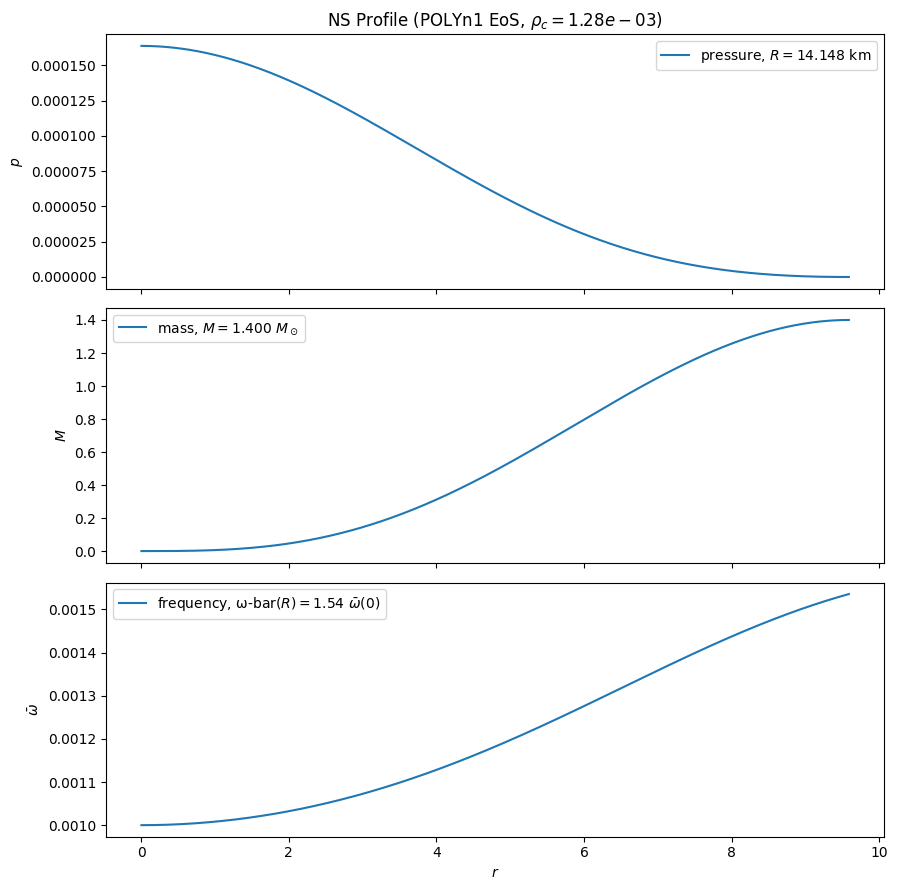

In [7]:
# Omega profile of one sample star

rho_c = 1.28e-3 #3.5 units of nuclear saturation 
p_central1 = eos_p(rho_c, 100, 2)

r, p, m, y2, H2, v, w, y3, ys3 = solve_tov_equations(                          
    p_central=p_central1,
    eos_rho=eos_rho_func,
    eos_cs2=eos_cs2_func,
    step=0.005
)

dy32 = make_dy32(eos_rho_func, eos_cs2_func, w, Om, y2, H2, r)
y32_path = integrate_auxiliary_2(r, p, m, w, [H20, 4.0], dy32)
Y32 = y32_path[-1,1]
        
R = r[-1]
M = m[-1]
#Y2 = y2[-1]
#Y3 = y3[-1]
#Ys3 = ys3[-1]
W = w[-1]
h2 = H2[-1]

   #Plotting
fig, axes = plt.subplots(figsize=(9, 9), nrows=3, sharex=True)

axes[0].plot(r, p, label=r"pressure, $R = {:.3f}$".format(R*1.476)+" km")
axes[1].plot(r, m, label=r"mass, $M = {:.3f}$".format(M)+" $M_\odot$")
axes[2].plot(r, w, label=r"frequency, ω-bar$(R) = {:.2f}$".format(W/Om)+r" $\bar{\omega}(0)$")
#axes[2].plot(r, H2, label=r"$H_2$ pertubation")

axes[0].set_title(r"NS Profile (POLYn1 EoS, $\rho_c = {:.2e}$".format(rho_c)+")")
axes[0].set_ylabel(r"$p$")
axes[0].legend()

axes[1].set_ylabel(r"$M$")
axes[1].legend()

axes[2].set_ylabel(r"$\bar{\omega}$")
axes[2].set_xlabel(r"$r$")
axes[2].legend()

#axes[2].set_ylabel(r"$H_2$")
#axes[2].set_xlabel(r"$r$")
#axes[2].legend()

fig.tight_layout()
plt.show()

#fig.savefig("NS_POLYn1_profs_with_spin.png", bbox_inches='tight', dpi=300)

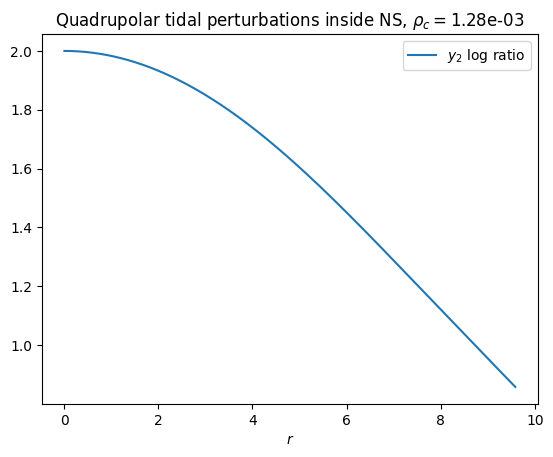

In [8]:
f= plt.figure()
#plt.plot(r, H2, label=r"$H_2$ pertubation, $H_2(0)=${:.1e}".format(H20))
plt.plot(r, y2, label=r"$y_2$ log ratio")
plt.title(r"Quadrupolar tidal perturbations inside NS, $\rho_c=${:.2e}".format(rho_c))
#plt.ylabel(r"$H_2$")
plt.xlabel(r"$r$")
plt.legend()
#plt.grid()
plt.show();

#f.savefig("NS_POLYn1_H2_v2.png", bbox_inches='tight', dpi=300)

## MRL data

In [5]:
#By varying the central density, we obtain possible values for mass, radius, and log ratio: 

rho_base = 1.28e-3
rho_min = 1/5 * rho_base
rho_max = 6 * rho_base

def POLYn1_eos_MRLY(eos_p,
                   eos_rho,
                   eos_cs2,
                   rho_central_start=rho_min,
                   rho_central_log_step=0.05,
                   rho_central_stop=rho_max,
                   stop_at_maximum_mass=False):

    data = pd.DataFrame(
        columns=['rho_central', 'M', 'R', 'k2', 'Lambda2', 'h2','W', 'k3', 'ks3', 'Y2', 'Ys3', 'Y32', 'P']).set_index('rho_central')
    rho_central = rho_central_start
    while rho_central < rho_central_stop:
        # Central pressure
        p_central = eos_p(rho_central)
        # Solve TOV + tidal
        r, p, m, y2, H2, v, w, y3, ys3 = solve_tov_equations(
            p_central=p_central,
            eos_rho=eos_rho,
            eos_cs2=eos_cs2,
            step=0.001)

        dy32 = make_dy32(eos_rho, eos_cs2, w, Om, y2, H2, r)
        y32_path = integrate_auxiliary_2(r, p, m, w, [H20, 4.0], dy32)
        Y32 = y32_path[-1,1]

        R = r[-1]
        M = m[-1]
        Y2 = y2[-1]
        Y3 = y3[-1]
        Ys3 = ys3[-1]
        W = w[-1]
        h2 = H2[-1]

        C = M / R

        if C < 1e-10:
            k2, P, k3, ks3 = np.nan
        else:
            log = np.log(1 - 2*C)

            k2=((8 * C**5 / 5) * (1 - 2*C)**2 * (2 + 2*C*(Y2 - 1) - Y2))/((2*C*(6 - 3*Y2 + 3*C*(5*Y2 - 8)) +
        4*C**3*(13 - 11*Y2 + C*(3*Y2 - 2) + 2*C**2*(1 + Y2)) +
        3*(1 - 2*C)**2 * (2 - Y2 + 2*C*(Y2 - 1)) * log))

            k3=((8 * C**7 / 7) * (1 - 2*C)**2 * (2*C**2*(Y3-1)-3*C*(Y3-2)+Y3-3))/(2*C*(4*C**5*(Y3+1) + 
        2*C**4*(9*Y3-2)+20*C**3*(9-7*Y3)+5*C**2*(37*Y3-72)+45*C*(5-2*Y3)+15*(Y3-3))
        + 15*(1-2*C)**2*(-3+Y3+C*(6+2*C*(Y3-1)-3*Y3))* log)

            ks3=((3 * C**7) * (3*(Ys3-4)-10*C*(Ys3-3) + C**2*(Ys3 - 2)))/(98*C*(45*(Ys3-4) + 
        30*C**2*(Ys3-1)+10*C**3*Ys3+4*C**4*(Ys3+1)-15*C*(7*Ys3-18)) 
        + 735*(3*(Ys3-4)-10*C*(Ys3-3)+8*C**2*(Ys3-2)) * log)

            arccoth = log/2

            P = -((45*(4*C*(585*(-4+Y32)+C*(8190-2535*Y32+2*C*(195*(-19+8*Y32)
                                                              +2*C*(13-14*Y32+2*C*(23+68*Y32+18*C*(2+Y32))))))+
                      -18*(-1+2*C)*(405*(-4+Y32)+2*C*(2025-1080*C+32*C**4+(-5+4*C)*(135+8*C**3)*Y32))*arccoth
                      +825*(-1+2*C)*(3*(-4+Y32)-10*C*(-3+Y32)+8*C**2*(-2+Y32))*log))/(
                12544*(-1+2*C)*(30*C**2*(18-7*Y32)+90*C*(-4+Y32)+60*C**3*(-1+Y32)+20*C**4*Y32+8*C**5*(1+Y32)
                               +15*(3*(-4+Y32)-10*C*(-3+Y32)+8*C**2*(-2+Y32))*log)))
            
           
        if np.isfinite(k2) and k2 > 0:
                Lambda2 = (2/3) * k2 / C**5
        else:
                Lambda2 = np.nan
                
        
        # Optional stopping at maximum mass
        if stop_at_maximum_mass and len(data) > 0:
            if M < data['M'].iat[-1]:
                break

        data.loc[rho_central] = [M, R, k2, Lambda2, h2, W, k3, ks3, Y2, Ys3, Y32, P]

        # Log stepping
        rho_central += rho_central * rho_central_log_step
    return data

eos_p_func, eos_rho_func = POLYn1_eos_p_and_rho()
eos_cs2_func, _ = POLYn1_eos_cs2_and_rho()

POLYn1_data = POLYn1_eos_MRLY(eos_p=eos_p_func,
                              eos_rho=eos_rho_func,
                              eos_cs2=eos_cs2_func,
                              );


/tmp/ipykernel_7743/1619362509.py:34: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / K)**(1/Gamma)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/tmp/ipykernel_7743/1619362509.py:34: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / K)**(1/Gamma)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/tmp/ipykernel_7743/1619362509.py:34: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / K)**(1/Gamma)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/tmp/ipykernel_7743/1619362509.py:34: Ru

In [6]:
#extract the computations

rho_vals = POLYn1_data.index.values
M_vals = POLYn1_data['M'].values
R_vals = POLYn1_data['R'].values
k2_vals = POLYn1_data['k2'].values
k3_vals = POLYn1_data['k3'].values
ks3_vals = POLYn1_data['ks3'].values
Lambda_vals = POLYn1_data['Lambda2'].values
Y2_vals = POLYn1_data['Y2'].values
Ys3_vals = POLYn1_data['Ys3'].values
Y32_vals = POLYn1_data['Y32'].values
P_vals = POLYn1_data['P'].values
W_vals = POLYn1_data['W'].values
H2_vals = POLYn1_data['h2'].values


In [7]:
#To see how these terms are computed as

print(P_vals)

[4623.33252107 4089.17560234 3620.25417301 3208.34518752 2846.26735315
 2527.76893502 2247.40014991 2000.4140121  1782.66897988 1590.55216458
 1420.91108995 1270.99352907 1138.3860957  1020.99614787  916.98250335
  824.73698085  742.85173231  670.09570022  605.38702445  547.78039257
  496.44407252  450.65010514  409.75811778  373.20551138  340.49730426
  311.19830674  284.92525114  261.33990607  240.14497149  221.07742471
  203.90533504  188.42341437  174.45032684  161.82574745  150.40741247
  140.0692895   130.69958901  122.1992406   114.47952908  107.46257864
  101.07838755   95.26518696   89.96594934   85.13304913   80.72161439
   76.69242351   73.00960298   69.64237913   66.56155979   63.74251012
   61.16227221   58.80044773   56.63873006   54.66083755   52.85151362
   51.19798001   49.68817479   48.31137376   47.05790678   45.9192607
   44.88762739   43.9561329    43.11855566   42.36939684   41.70376532
   41.11733188   40.60628339   40.16731185   39.79739742   39.4941751 ]


## Pani plots

In https://arxiv.org/abs/1509.02171, their Fig 2 shows a plot of the ratio
\begin{equation}
\mathrm{Pani~ notation:}\quad\frac{\delta\tilde{\lambda}^{(23)}}{|\tilde{\lambda}^{(2)}|}
\end{equation}
across various choices of EoS (including simple polytrope) over the range in compactness $C\in[0.05,\,0.3]$. Eq. (42) in Pani II shows a representative expression for $\delta\tilde{\lambda}_{(32)}$, independent of EoS:  
\begin{equation}
\delta\tilde{\lambda}_{(32)}=\chi\frac{A_1+A_2\log(1-2C)}{A_3+A_4\log(1-2C)+A_5\log(1-2C)^2},
\end{equation}
where $A_i$ are cumbersome polynomials dependent on $C$ and surface-level logarithmic ratios $y_l^{(*)}(R)$. We recognize that Eq. (42) -- denoting a dimensonless quantity $\delta\lambda_{(32)}/(\chi M^6)$ -- is scaled by $\chi$, where the tilde quantity has the scaling.

Similar to the representative expression for $\delta\tilde{\lambda}_{(32)}$, we represent $\tilde{\lambda}_{(2)}$ for completeness as
\begin{equation}
\tilde{\lambda}_{(2)}=\frac{A_6}{A_7+A_8\log(1-2C)},
\end{equation}
where the absolute value is applied due to a negative scaling in Pani's convention (Geroch-Hansen moments). Thus, the ratio $\delta\tilde{\lambda}_{(32)}/|\tilde{\lambda}_{(2)}|$ is
\begin{equation}
\frac{\delta\tilde{\lambda}_{(32)}}{|\tilde{\lambda}_{(2)}|}=\frac{1}{A_6}\frac{\left(A_1+A_2\log(1-2C)\right)\left(A_7+A_8\log(1-2C)\right)}{A_3+A_4\log(1-2C)+A_5\log(1-2C)^2}.
\end{equation}

It is found using a representative analysis that Pani II Eq. (42) best describes the coupling $p_{23}k_{2}C$, which follows the same representative profile. In terms of the Love numbers and polynomials we know, the ratio is expected to follow the form, readily  inserting the scaling factors from symmetric normalizations:
\begin{equation}
\frac{\delta\tilde{\lambda}_{(32)}}{|\tilde{\lambda}_{(2)}|}\sim p_{23}.
\end{equation}
Here, for POLYn1, $k_2,\,p_{32}$ are sourced from the varied data, to be plotted with the computed compactness from the EoS.

We basically recycle the simple polytrope data after solving the TOV equations over a range of varied densities. To make it as true to the figure as possible, we plot the Pani ratio over all computations of $C=M/R$, but cut the x-axis range to $C\in[0.05,\,0.3]$.

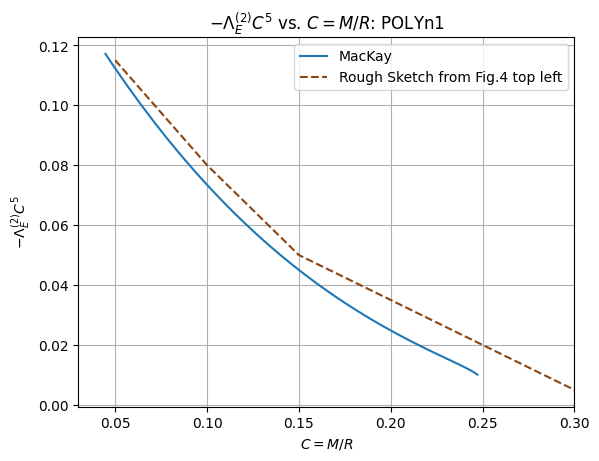

In [11]:
#-\tilde{\lambda}^{(2)}_E C^5 vs. C=M/R

f1 = plt.figure()

plt.plot(M_vals/R_vals, (5/np.pi)**(1/2)*k2_vals/2, label='MacKay')    
plt.plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([0.115, 0.08, 0.05, 0.035, 0.005]), 
         label=r"Rough Sketch from Fig.4 top left", ls="--", color='saddlebrown')

plt.ylabel("$-\Lambda^{(2)}_E C^5$")
plt.xlabel("$C=M/R$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.xlim([0.03, 0.3])
plt.title("$-\Lambda^{(2)}_E C^5$ vs. $C=M/R$: POLYn1")
plt.legend();

#f1.savefig("lam2c5_vs_c_POLYn1.png", bbox_inches='tight', dpi=300)


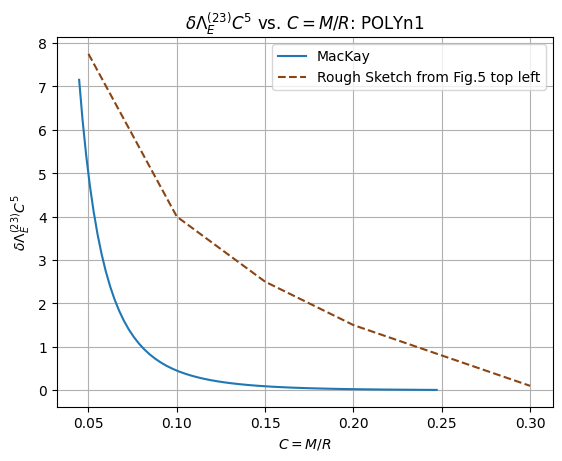

In [12]:
#\delta\tilde{\lambda}^{(23)}_E C^5 vs. C=M/R

def deltlam(x, k2_v, p32_v, M_v, R_v):
    C = M_v/R_v
    k2 = k2_v
    p32 = p32_v
    return x*p32*k2

dl23 = deltlam(0.05, k2_vals, P_vals, M_vals, R_vals)/6

f2 = plt.figure()

plt.plot(M_vals/R_vals, dl23, label='MacKay')    
plt.plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([7.75, 4, 2.5, 1.5, 0.1]), 
         label=r"Rough Sketch from Fig.5 top left", ls="--", color='saddlebrown')

plt.ylabel("$\delta\Lambda^{(23)}_E C^5$")
plt.xlabel("$C=M/R$")
plt.grid()
plt.grid(which="minor", color="0.85")
#plt.xlim([0.05, 0.3])
#plt.ylim([-1, 14])
plt.title("$\delta\Lambda^{(23)}_E C^5$ vs. $C=M/R$: POLYn1")
plt.legend();

#f2.savefig("dl23c5_vs_c_POLYn1.png", bbox_inches='tight', dpi=300)


In [63]:
print(np.array([7.75, 4, 2.5, 1.5, 0.1])/np.array([0.115, 0.08, 0.05, 0.035, 0.005]))

[67.39130435 50.         50.         42.85714286 20.        ]


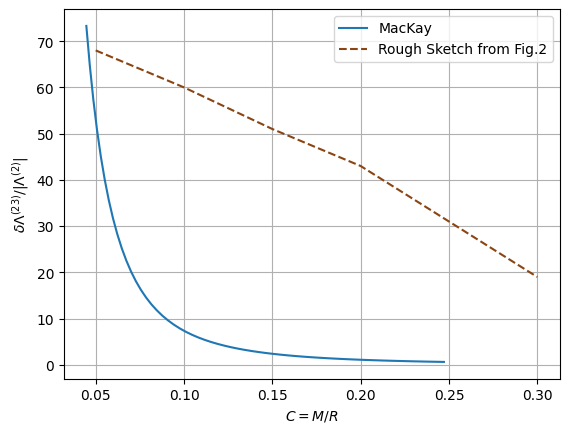

In [13]:
plt.plot(M_vals/R_vals, 0.05*P_vals/((5/np.pi)**(1/2)/2)/5, label=r"MacKay")
plt.plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([68, 60, 51, 43,  19]), 
         label=r"Rough Sketch from Fig.2", ls="--", color='saddlebrown')
plt.ylabel("$\delta\Lambda^{(23)}/|\Lambda^{(2)}|$")
#plt.ylim([10, 250])
#plt.yscale('log')
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend()
plt.xlabel("$C=M/R$");

There's reason to believe, after reading the text below Eq. (42), that the published curve may be plotted by another polynomial solved by the $\delta H^{(2)}$ function and coupled to $k^*_3$. However, the Newtonian limit to this coupling is instead $\sim 1/C^4$, which does not agree with what Pani et al originally claimed to be the $\delta\tilde{\lambda}^{(23)}$ Newtonian limit.

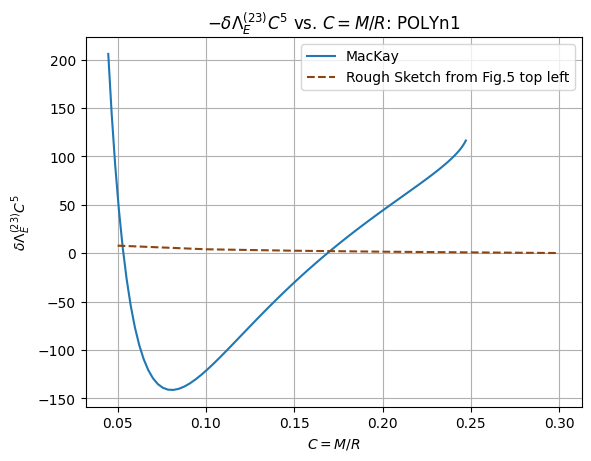

In [16]:
def p23(y23_v, M_v, R_v):
    C=M_v/R_v
    y23=y23_v
    log = np.log(1-2*C)
    return (224*(7/5)**(1/2)*(2*C*(210*(-2+y23)+8*C**6*(2+y23)+8*C**7*(4+y23)+6*C**5*(8+5*y23)
                                  -30*C*(-59+38*y23)+4*C**4*(29+38*y23)-5*C**3*(-80+279*y23))
           +15*(1-2*C)**2*(14*(-2+y23)-34*C*(-1+y23)+19*C**2*y23)*log))/(
        C*(2*C*(6+C**2*(26-22*y23)-3*y23+4*C**4*(1+y23)+3*C*(-8+5*y23)+C**3*(-4+6*y23))
           +3*(1-2*C)**2*(2+2*C*(-1+y23)-y23)*log)
           )

#if the discussion on the tidal ODE with a source term in thesis still holds,
#the solution to a sourced ODE approximates to the solution to the respective sorceless ODE, given ultra-small initial
#conditions for e.g. Omega for internal frequency and H (or h) at r=0.

dl23new= p23(Y2_vals, M_vals, R_vals)*ks3_vals

plt.plot(M_vals/R_vals, 0.05*dl23new, label='MacKay')    
plt.plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([7.75, 4, 2.5, 1.5, 0.1]), 
         label=r"Rough Sketch from Fig.5 top left", ls="--", color='saddlebrown')

plt.ylabel("$\delta\Lambda^{(23)}_E C^5$")
plt.xlabel("$C=M/R$")
plt.grid()
plt.grid(which="minor", color="0.85")
#plt.xlim([0.05, 0.3])
#plt.ylim([-1, 14])
plt.title("$-\delta\Lambda^{(23)}_E C^5$ vs. $C=M/R$: POLYn1")
plt.legend();

Probably not..

What if the initial $p_{32}$ polynomial is instead set by $y_2$?

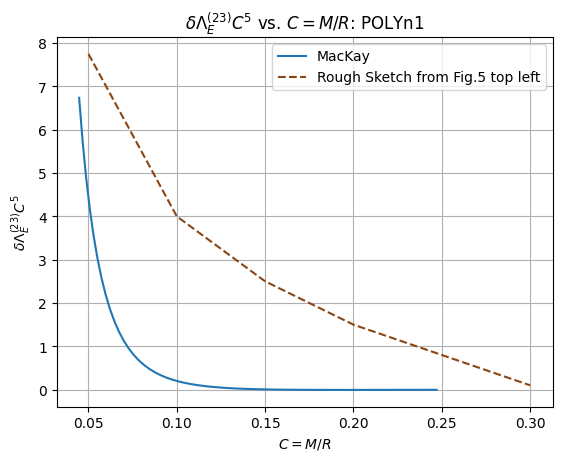

In [19]:
def p23n(y23_v, M_v, R_v):
    C=M_v/R_v
    Y32=y23_v
    log = np.log(1-2*C)
    arccoth = log/2
    return -((45*(4*C*(585*(-4+Y32)+C*(8190-2535*Y32+2*C*(195*(-19+8*Y32)
                                                              +2*C*(13-14*Y32+2*C*(23+68*Y32+18*C*(2+Y32))))))+
                      -18*(-1+2*C)*(405*(-4+Y32)+2*C*(2025-1080*C+32*C**4+(-5+4*C)*(135+8*C**3)*Y32))*arccoth
                      +825*(-1+2*C)*(3*(-4+Y32)-10*C*(-3+Y32)+8*C**2*(-2+Y32))*log))/(
                12544*(-1+2*C)*(30*C**2*(18-7*Y32)+90*C*(-4+Y32)+60*C**3*(-1+Y32)+20*C**4*Y32+8*C**5*(1+Y32)
                               +15*(3*(-4+Y32)-10*C*(-3+Y32)+8*C**2*(-2+Y32))*log)))

dl23new2= 0.05*p23n(Y2_vals, M_vals, R_vals)*k2_vals

plt.plot(M_vals/R_vals, -dl23new2/3, label='MacKay')    
plt.plot(np.array([0.05, 0.1, 0.15, 0.2,  0.3]), np.array([7.75, 4, 2.5, 1.5, 0.1]), label=r"Rough Sketch from Fig.5 top left", ls="--", color='saddlebrown')

plt.ylabel("$\delta\Lambda^{(23)}_E C^5$")
plt.xlabel("$C=M/R$")
plt.grid()
plt.grid(which="minor", color="0.85")
#plt.xlim([0.05, 0.3])
#plt.ylim([-1, 14])
plt.title("$\delta\Lambda^{(23)}_E C^5$ vs. $C=M/R$: POLYn1")
plt.legend();

Conclusion: It is truly unclear (to me) how Pani et al originally plotted their Figures 2 and 4. Neither the literature nor its Mathematica notebook supplement was very enlightening; attempts to reproduce these failed at face value, showing visual mismatch between the the literature renderings and my computations.

## Misc.

In [36]:

def totx1(x, k2, M, R, p):
    C=M/R
    return (2/3)*(1 + (x/20)*p*(5/7)**(1/2)*(M/(5*R))*(2*M/(5*R))**(1/2))* k2 * C**(-5)

def totx2(x, k2, ks3, M, R, p):
    C = M/R
    return (2/3)*(1 - (x**2/700)*(p*C)**2*(k2/ks3)(35)**(1/2)) * k2 * C**(-5)

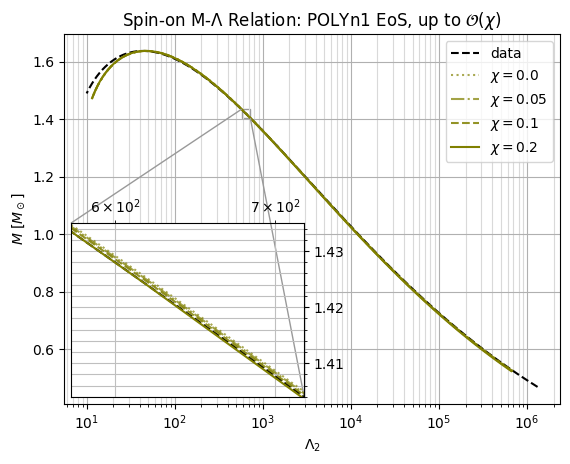

In [31]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

chip=[0.00, 0.05, 0.10, 0.20]
chin=[0.00, -0.05, -0.10, -0.20]

ls_rack=[':','-.','--','-']
alphs=[0.675, 0.725, 0.85, 1]

fig, ax = plt.subplots()

ax.semilogx(dataL_POLYn1, dataM_POLYn1,
            color='black', ls='--', label='data')

for x, lsd, a in zip(chip, ls_rack, alphs):
    lamx1 = totx1(x, k2_vals, M_vals, R_vals, P_vals)
    ax.semilogx(lamx1, M_vals,
                color='olive', ls=lsd, alpha=a,
                label=rf"$\chi={x}$")

ax.set_xlabel(r"$\Lambda_2$")
ax.set_ylabel(r"$M$ [$M_\odot$]")
ax.set_title("Spin-on M-Λ Relation: POLYn1 EoS, up to $\mathcal{O}(\chi)$")
ax.grid()
ax.grid(which="minor", color="0.85")
ax.legend()

# Create inset
axins = inset_axes(ax, width="47%", height="47%", loc='lower left')

# Plot the same curves
axins.semilogx(dataL_POLYn1, dataM_POLYn1,
               color='black', ls='--')

for x, lsd, a in zip(chip, ls_rack, alphs):
    lamx1 = totx1(x, k2_vals, M_vals, R_vals, P_vals)
    axins.semilogx(lamx1, M_vals,
                   color='olive', ls=lsd, alpha=a)

# Set zoom region
axins.set_xlim(575, 720)
axins.set_ylim(1.404, 1.435)
#axins.set_xticks([])
#axins.set_yticks([])
axins.xaxis.tick_top()
axins.yaxis.tick_right()
axins.tick_params(
    labeltop=True,
    labelbottom=False,
    labelright=True,
    labelleft=False
)
axins.grid(which='major', color='0.75')
axins.grid(which='minor', color='0.75')
axins.minorticks_on()   # if needed


# Connect inset to main plot
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.6")

plt.show()
#f.savefig("chi1_MLcurve_POLYn1.png", bbox_inches='tight', dpi=300)

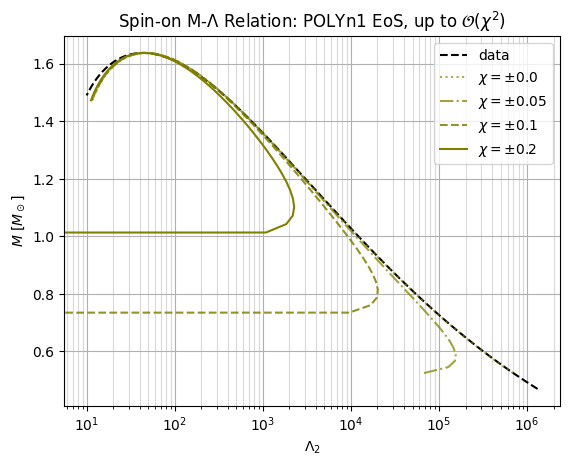

In [37]:
chi=[0.00, 0.05, 0.10, 0.20]
ls_rack=[':','-.','--','-']
alphs=[0.675, 0.725, 0.85, 1]

f = plt.figure()

plt.semilogx(dataL_POLYn1, dataM_POLYn1, color='black', ls = '--', label='data')    

for x, lsd, a in zip(chi, ls_rack, alphs):
    lamx2 = totx2(x, k2_vals, ks3_vals, M_vals, R_vals, P_vals)
    plt.semilogx(lamx2, M_vals, color='olive', ls=lsd, alpha=a, label=rf"$\chi=\pm{x}$")
   
plt.xlabel("$\Lambda_2$")
plt.ylabel("$M$ [$M_\odot$]")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.title("Spin-on M-Λ Relation: POLYn1 EoS, up to $\mathcal{O}(\chi^2)$")
plt.legend();

#f.savefig("chi2_MLcurve_POLYn1.png", bbox_inches='tight', dpi=300)